# E2: a fresh NL→FOL faithfulness test set (partial, stopped by budget)

This notebook demos the **`data.py`** script from the *E2* dataset artifact. E2 is a fresh confirmation set for
**metrics that judge whether a first-order-logic (FOL) formula faithfully says what an English sentence says**,
with no gold formula available at scoring time. It shares no sentences with the earlier dataset **E**, and it is labelled by E's
byte-identical, frozen code.

**State of the artifact.** Generation stopped when the shared OpenRouter budget ran out. What exists:
* **550 pre-registered sentences** with gold references: L25 (MALLS, ≥25 words, ≥3 conditions) ×350, EXC (exceptions) ×100, DT (ProverQA) ×100.
  Only the 30 **pilot** sentences have candidates. The other 520 have the status `PENDING_GENERATION_BUDGET_STOP`.
* **300 real candidates** (10 LLM systems × 30 pilot sentences) and **30 gold-as-system rows**, labelled by E's solver-based labeller.
  Without panel votes, E's final rule yields only `ERROR`, `UNRESOLVED` or `UNPARSEABLE`, with 0 `CORRECT`.
* **A partial panel-drift check.** E's 3-model LLM panel was replayed with a fresh cache on the 77 synthetic gate items. The track-H replay was cut off.

**What `data.py` does.** It does no labelling and computes no metric. It is the *final assembly and provenance check*.
It takes the assembled rows and **re-verifies every row against the raw sources**:
* candidate: the raw LLM output must equal the last generation record, and `normalise(raw)` must equal the stored `candidate_fol`;
* gold-as-system and sentence rows: the text and gold formula must equal the MALLS / ProverQA source record;
* panel drift: the row joins E's stored votes with today's replay votes.

It then writes `full_data_out.json` (with `mini` and `preview` variants) in the pipeline's `exp_sel_data_out` layout.

The demo runs the same code on `mini_demo_data.json`, a 90-row subset bundled with **exactly the inputs `data.py` reads**:
the assembled rows, the source records they are checked against, the generation records, and the panel caches.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install (data.py logs through it)
_pip('loguru==0.7.3')

# numpy, pandas, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')

In [2]:
# --- original import block of data.py ---
from __future__ import annotations

import json
import sys
from collections import Counter
from pathlib import Path

from loguru import logger

# --- imports used by normalise() (copied from src/normalise.py, which data.py imports) ---
import re
import unicodedata

# --- extra imports for the notebook's summary / plots ---
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_An1uy2kF2SjZ/round-4/dataset-4/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(json.dumps(data["metadata"], indent=1))
print({k: (len(v) if isinstance(v, (list, dict)) else v) for k, v in data.items() if k != "metadata"})

{
 "description": "Demo bundle for the E2 NL->FOL faithfulness confirmation set (budget-stopped, partial). Holds the inputs data.py reads, cut to a small subset: assembled rows, the source records they are checked against, the generation records, and the panel-drift inputs.",
 "n_rows": {
  "e2_candidates": 40,
  "e2_gold_as_system": 10,
  "e2_sentences": 20,
  "e2_panel_drift": 20
 },
 "panel_prompt_sha1": "0b5ffbb951ec3d5489bb64812387b064354cc905"
}
{'assembled_E2': 2, 'controls_E2': 2, 'sources': 5, 'generations': 40, 'calibration_items': 12, 'panel_cache_E': 81, 'panel_cache_E2': 27, 'trackh_panel_rows_E': 8, 'trackh_panel_rows_E2': 8}


## Config

`data.py` has no training-style knobs. The only scale parameter is **how many rows of each group** go through the
verify-and-assemble pass. The bundle holds 40 candidates, 10 gold-as-system rows, 20 sentences, 12 synthetic
panel-drift items and 8 track-H pairs, and the demo uses all of them. The original run used every row of the full
artifact: 300 / 30 / 550 / 77 / 96. `LIMIT`, the preview truncation length and the size of the `mini` output are
the script's own constants. They appear here unchanged.

In [5]:
# rows per group taken from the bundle (None = all rows in mini_demo_data.json)
N_CANDIDATES = None      # bundle: 40   | original full run: 300
N_GOLD_AS_SYSTEM = None  # bundle: 10   | original: 30
N_SENTENCES = None       # bundle: 20   | original: 550
N_DRIFT_SYNTH = None     # bundle: 12   | original: 77 synthetic gate items
N_DRIFT_TRACKH = None    # bundle: 8    | original: 96 track-H pairs

# data.py's own constants (unchanged)
LIMIT = 100 * 1000 * 1000   # max bytes of full_data_out.json before a split is required
PREVIEW_TRUNC = 200         # _trunc(): preview strings cut to this many characters
MINI_N = 3                  # rows per group in mini_data_out.json

OUT_DIR = "demo_out"        # where the notebook writes full/mini/preview_data_out.json + logs

Apply the config to the loaded bundle. Each group is cut to its first `N` rows. The panel caches and
generation records are left whole, because they are lookup tables and not rows.

In [6]:
_g = {x["dataset"]: x for x in data["assembled_E2"]["datasets"]}
_g["e2_candidates"]["examples"] = _g["e2_candidates"]["examples"][:N_CANDIDATES]
_g["e2_gold_as_system"]["examples"] = _g["e2_gold_as_system"]["examples"][:N_GOLD_AS_SYSTEM]
_g["e2_sentences"]["examples"] = _g["e2_sentences"]["examples"][:N_SENTENCES]
data["calibration_items"] = data["calibration_items"][:N_DRIFT_SYNTH]
data["trackh_panel_rows_E"] = data["trackh_panel_rows_E"][:N_DRIFT_TRACKH]
print({k: len(v["examples"]) for k, v in _g.items()}, len(data["calibration_items"]), len(data["trackh_panel_rows_E"]))

{'e2_candidates': 40, 'e2_gold_as_system': 10, 'e2_sentences': 20} 12 8


## Setup: paths, logging, constants

This is `data.py`'s module header. There is one change: `ROOT` is now the notebook's output folder instead of the artifact
directory. The input paths `TD`, `W` and `E_DIR` are kept for reference only (`E_DIR` was an absolute server path and is now a placeholder). Every read that used them now comes from `data`.
The two `sys.path` imports (`normalise` and `drift_report`) are replaced by copies of those functions in the next two cells.

In [7]:
ROOT = Path(OUT_DIR)   # original: Path(__file__).resolve().parent (the artifact workspace)
ROOT.mkdir(exist_ok=True)
# original: sys.path.insert(0, str(ROOT / "src")); sys.path.insert(0, str(ROOT / "labeller"))
sys.setrecursionlimit(10000)
# original: from normalise import normalise  -> defined in the next cell

TD = ROOT / "temp" / "datasets"   # original source dir; its files are now data["sources"] / data["generations"]
W = ROOT / "work"                 # original work dir; its files are now data["assembled_E2"], data["controls_E2"], ...
E_DIR = Path("E")  # original: absolute path to dataset E's workspace; E's panel cache + track-H rows are now in data
(ROOT / "logs").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "data_py.log", rotation="30 MB", level="DEBUG")
FORBIDDEN = {"split", "dataset", "context"}
# LIMIT is set in the config cell (100 * 1000 * 1000)
Q_PREFIX = "Based on the above information, is the following statement true, false, or uncertain? "

## E's frozen output normaliser (`src/normalise.py`)

`data.py` re-runs this function to check that each stored `candidate_fol` is exactly `normalise(raw_output)`.
It does **only surface-syntax mapping** and never repairs meaning: it strips code fences and the `FOL:` prefix, keeps the first
line, unwraps LaTeX, maps ASCII connectives and quantifiers to Unicode, and folds diacritics in letters.

In [8]:
LATEX = [
    (r"\\text\{([^{}]*)\}", r"\1"), (r"\\mathrm\{([^{}]*)\}", r"\1"), (r"\\operatorname\{([^{}]*)\}", r"\1"),
    (r"\\forall\s*", "∀"), (r"\\exists\s*", "∃"), (r"\\land\b|\\wedge\b", "∧"), (r"\\lor\b|\\vee\b", "∨"),
    (r"\\neg\b|\\lnot\b", "¬"), (r"\\leftrightarrow\b|\\iff\b|\\Leftrightarrow\b", "↔"),
    (r"\\rightarrow\b|\\to\b|\\Rightarrow\b|\\implies\b", "→"), (r"\\oplus\b", "⊕"),
    (r"\\\(|\\\)|\\\[|\\\]|\$", ""), (r"\\[,;!: ]", " "),
]
WORDOPS = [
    (r"\bforall\s+([a-z][a-z0-9]*)\s*[.:]?", r"∀\1 "), (r"\ball\s+([a-z])\s*\.", r"∀\1 "),
    (r"\bexists\s+([a-z][a-z0-9]*)\s*[.:]?", r"∃\1 "), (r"\bexist\s+([a-z])\s*\.", r"∃\1 "),
    (r"<->|<=>|⟷|⇔|≡", "↔"), (r"->|=>|⟶|⇒|⊃", "→"), (r"&&|&", "∧"), (r"\|\||\|", "∨"),
    (r"\bxor\b|⊻", "⊕"), (r"\bnot\s+", "¬"), (r"[~!]|¬", "¬"), (r"\band\b", "∧"), (r"\bor\b", "∨"),
]


def normalise(raw: str | None) -> tuple[str, list[str]]:
    applied: list[str] = []
    if raw is None:
        return "", ["none"]
    s = raw.strip()
    if "```" in s:
        m = re.search(r"```(?:[a-zA-Z]*)\n?(.*?)```", s, re.S)
        if m:
            s = m.group(1).strip()
            applied.append("code_fence")
    m = re.search(r"FOL\s*[:：]\s*(.+)", s)
    if m:
        s = m.group(1)
        applied.append("fol_prefix")
    lines = [ln.strip() for ln in s.splitlines() if ln.strip()]
    if len(lines) > 1:
        applied.append("first_line")
    s = lines[0] if lines else ""
    if "\\" in s or "$" in s:
        for a, b in LATEX:
            s = re.sub(a, b, s)
        applied.append("latex")
    s2 = s
    for a, b in WORDOPS:
        s2 = re.sub(a, b, s2)
    if s2 != s:
        applied.append("ascii_ops")
    s = s2.strip().strip("`").strip()
    s = re.sub(r"\s+", " ", s).rstrip(".")
    folded = "".join(_fold(ch) for ch in s)
    if folded != s:
        applied.append("ascii_fold")
        s = folded
    return s, applied


def _fold(ch: str) -> str:
    # Diacritic folding of non-ASCII LETTERS only (Sūduva -> Suduva); logic symbols are untouched.
    if ch.isascii() or not unicodedata.category(ch).startswith("L"):
        return ch
    base = "".join(c for c in unicodedata.normalize("NFKD", ch) if not unicodedata.combining(c))
    return base if base.isascii() and base else "_"


print(normalise("FOL: forall x (Dog(x) -> ~Cat(x))."))

('∀x (Dog(x) → ¬Cat(x))', ['fol_prefix', 'ascii_ops'])


## Panel-vote readers (`src_e2/drift_report.py`)

`drift_rows()` imports these two helpers. `calib_votes` collects each panel member's faithful/unfaithful verdict for the
synthetic gate items from a panel cache. It only counts parsed records made with the frozen panel prompt (`PROMPT_SHA1`).
`trackh_votes` does the same for the original and corrected formula of each track-H real-error pair.
The one change: `calib_votes` takes the cache **records** from `data` instead of opening a `.jsonl` path, and
`PROMPT_SHA1` is read from the bundle instead of being rebuilt from `src/panel.py`'s prompt template.

In [9]:
PROMPT_SHA1 = data["metadata"]["panel_prompt_sha1"]  # original: from panel import PROMPT_SHA1
MEM = ["P1", "P3", "R1"]   # P1 = claude-haiku-4.5, P3 = glm-4.6, R1 = kimi-k2-0905


def calib_votes(cache_rows: list) -> dict:   # original: calib_votes(cache_path: Path), iterating open(cache_path) lines
    out: dict = {}
    for r in cache_rows:
        if r.get("parsed") and r["sentence_id"].startswith("calib|") and r["prompt_sha1"] == PROMPT_SHA1 and r["member"] in MEM:
            for cid, v in r["verdicts"].items():
                key = cid if cid != "REF" else "REF|" + r["sentence_id"]
                out.setdefault(key, {})[r["member"]] = bool(v["faithful"])
    return out


def trackh_votes(rows: list) -> dict:
    out = {}
    for r in rows:
        for m, v in r["votes"].items():
            if m in MEM:
                out.setdefault(f"H{r['id']}:orig", {})[m] = bool(v["orig_faithful"])
                out.setdefault(f"H{r['id']}:corr", {})[m] = bool(v["corr_faithful"])
    return out

## Source index: text → (gold FOL, source file)

The helpers from the top of `data.py`. `source_index()` maps every source sentence to its gold formula. It covers MALLS-v0.1
train and test (`NL` → `FOL`) and ProverQA dev easy/medium/hard (each premise in `nl2fol`, plus the question minus its
fixed prefix → `conclusion_fol`). `setdefault` means the **first** file that contains a text wins.
The only change: each file comes from `data["sources"][f]` instead of `TD / f`. The bundle keeps just the records
that the demo rows touch.

In [10]:
def jl(p: Path) -> list[dict]:
    return [json.loads(l) for l in p.read_text(encoding="utf-8").splitlines() if l.strip()] if p.exists() else []


def source_index() -> dict:
    # text -> (gold, source_file) for every candidate source record.
    idx = {}
    for f in ("yuan-yang__MALLS-v0__MALLS-v0.1-train.json", "yuan-yang__MALLS-v0__MALLS-v0.1-test.json"):
        for r in data["sources"][f]:                      # original: json.loads((TD / f).read_text())
            idx.setdefault(r["NL"].strip(), (r["FOL"].strip(), f))
    for diff in ("easy", "medium", "hard"):
        f = f"opendatalab__ProverQA__dev_{diff}.json"
        for r in data["sources"][f]:                      # original: json.loads((TD / f).read_text())
            for t, fo in r["nl2fol"].items():
                idx.setdefault(t.strip(), (fo.strip(), f))
            q = r["question"][len(Q_PREFIX):] if r["question"].startswith(Q_PREFIX) else r["question"]
            idx.setdefault(q.strip(), (r["conclusion_fol"].strip(), f))
    return idx


print(len(source_index()), "source texts indexed")

109 source texts indexed


## Panel-drift rows

Each row is one replayed drift item. It carries **E's stored votes** next to **today's replay votes**, or `None` where the replay
was cut off by the budget stop. In the full run the track-H replay stopped part-way, so the stop rule stays UNDECIDED.
The 8 pairs in this bundle all have replay votes.
Synthetic gate items keep the gold label `FAITHFUL`/`UNFAITHFUL`. Track-H pairs have the fixed output
`ORIGINAL_UNFAITHFUL__CORRECTED_FAITHFUL`.

In [11]:
def drift_rows() -> list[dict]:
    # One row per replayed drift item with E's stored votes and today's votes (None where the replay was cut off).
    # original: sys.path.insert(0, str(ROOT / "src_e2")); from drift_report import calib_votes, trackh_votes  (defined above)
    items = data["calibration_items"]                    # original: json.loads((W / "calibration_items.json").read_text())
    old_c = calib_votes(data["panel_cache_E"])           # original: calib_votes(E_DIR / "work" / "panel_cache.jsonl")
    new_c = calib_votes(data["panel_cache_E2"])          # original: calib_votes(W / "panel_cache.jsonl")
    rows = []
    for it in items:
        rows.append({"input": json.dumps({"text": it["text"], "candidate_fol": it["variant_fol"], "reference_fol": it["reference_fol"]}, ensure_ascii=False),
                     "output": it["gold"], "metadata_fold": "E2_PANEL_DRIFT", "metadata_subset": "synthetic_gate",
                     "metadata_item": it["calib_id"], "metadata_variant_type": it["variant_type"],
                     "metadata_E_stored_votes": old_c.get(it["calib_id"]), "metadata_E2_replay_votes": new_c.get(it["calib_id"]),
                     "metadata_source_verified": True, "metadata_source_file": "E/work/calibration_items.json"})
    old_rows = data["trackh_panel_rows_E"]               # original: json.loads((E_DIR / "work" / "trackh_panel_rows.json").read_text())
    new_h = trackh_votes(data["trackh_panel_rows_E2"]) if data["trackh_panel_rows_E2"] else {}  # original: (W / "trackh_panel_rows.json")
    old_h = trackh_votes(old_rows)
    for r in old_rows:
        rows.append({"input": json.dumps({"text": r["text"], "original_fol": r["orig"], "corrected_fol": r["corr"]}, ensure_ascii=False),
                     "output": "ORIGINAL_UNFAITHFUL__CORRECTED_FAITHFUL", "metadata_fold": "E2_PANEL_DRIFT", "metadata_subset": "trackH_real_error_pairs",
                     "metadata_item": r["id"], "metadata_ambiguous_curated": r["ambiguous"],
                     "metadata_E_stored_votes": {"orig": old_h.get(f"H{r['id']}:orig"), "corr": old_h.get(f"H{r['id']}:corr")},
                     "metadata_E2_replay_votes": {"orig": new_h.get(f"H{r['id']}:orig"), "corr": new_h.get(f"H{r['id']}:corr")},
                     "metadata_source_verified": True, "metadata_source_file": "E/work/trackh_panel_rows.json"})
    return rows

## Preview truncation helper

This is the preview variant of the output. Every string is cut to `PREVIEW_TRUNC` characters, recursively.

In [12]:
def _trunc(o, n: int = PREVIEW_TRUNC):
    # Preview variant: every string truncated to n characters, recursively (aii-json preview convention).
    if isinstance(o, str):
        return o if len(o) <= n else o[:n] + "..."
    if isinstance(o, list):
        return [_trunc(x, n) for x in o]
    if isinstance(o, dict):
        return {k: _trunc(v, n) for k, v in o.items()}
    return o

## `main()`: verify every row against its source, then assemble

`main()` is `data.py`'s original function. For each group it rebuilds the row, sets `metadata_source_verified`, and counts the
`True`/`False` outcomes in `verified`. **No row is ever dropped**: a failed check is recorded, not filtered.
* **candidates.** The text must exist in a source. The **last** generation record for (sentence, slot, prompt variant) must exist,
  its `raw_output` must equal the stored raw output, and `normalise(raw)` must reproduce `candidate_fol`. The reference FOL moves out of `input`
  into `metadata_reference_fol`, so metric code only sees `(text, candidate_fol)`.
* **gold-as-system.** The candidate must equal the source's gold formula.
* **sentences.** The stored original reference must equal the source's gold.
* **controls.** In the budget-stopped run this group is empty. It is listed under `empty_groups_omitted`.

It then checks the schema (only `input`, `output` and `metadata_*` keys; `input` and `output` are strings) and writes the three output variants.
The changes: the inputs come from `data`, `mini` uses `MINI_N`, and outputs go to `OUT_DIR`.

In [13]:
@logger.catch(reraise=True)
def main():
    asm = data["assembled_E2"]                            # original: json.loads((W / "assembled_E2.json").read_text())
    g = {x["dataset"]: x["examples"] for x in asm["datasets"]}
    idx = source_index()
    gens = {}
    for r in data["generations"]:                         # original: jl(TD / "generations.jsonl")
        if r.get("raw_output") is not None:
            gens[(r["sentence_id"], r["slot"], r["prompt_variant"])] = r
    sent_by = {s["metadata_sentence_id"]: s for s in g["e2_sentences"]}
    verified = Counter()

    def vcheck(tag: str, ok: bool) -> bool:
        verified[f"{tag}_{ok}"] += 1
        return ok

    cands = []
    for r in g["e2_candidates"]:
        inp = json.loads(r["input"])
        sid = r["metadata_sentence_id"]
        src = idx.get(inp["text"].strip())
        gen = gens.get((sid, r["metadata_slot"], r["metadata_prompt_variant"]))
        ok = bool(src) and gen is not None and gen["raw_output"] == r["metadata_raw_output"] and normalise(gen["raw_output"])[0] == inp["candidate_fol"]
        r = dict(r)
        r["input"] = json.dumps({"text": inp["text"], "candidate_fol": inp["candidate_fol"], "system": inp["system"],
                                 "prompt_variant": inp["prompt_variant"]}, ensure_ascii=False)
        r["metadata_reference_fol"] = inp["reference_fol"]
        r["metadata_model"] = r["metadata_generator_model_id"]
        r["metadata_model_returned"] = gen.get("model_returned") if gen else None
        r["metadata_latency_s"] = None  # E's frozen generate.py does not record latency (documented in the card)
        r["metadata_source_verified"] = vcheck("cand", ok)
        r["metadata_source_file"] = src[1] if src else None
        cands.append(r)
    golds = []
    for r in g["e2_gold_as_system"]:
        inp = json.loads(r["input"])
        src = idx.get(inp["text"].strip())
        ok = bool(src) and src[0] == inp["candidate_fol"].strip()
        r = dict(r)
        r["input"] = json.dumps({"text": inp["text"], "candidate_fol": inp["candidate_fol"], "system": inp["system"],
                                 "prompt_variant": inp["prompt_variant"]}, ensure_ascii=False)
        r["metadata_reference_fol"] = inp["reference_fol"]
        r["metadata_source_verified"] = vcheck("gold", ok)
        r["metadata_source_file"] = src[1] if src else None
        golds.append(r)
    sents = []
    for r in g["e2_sentences"]:
        inp = json.loads(r["input"])
        src = idx.get(inp["text"].strip())
        ok = bool(src) and src[0] == r["metadata_original_reference_fol"].strip()
        r = dict(r)
        r["metadata_source_verified"] = vcheck("sent", ok)
        r["metadata_source_file"] = src[1] if src else None
        sents.append(r)
    ctrl = data["controls_E2"]["rows"] if data.get("controls_E2") else []   # original: read from W / "controls_E2.json" if it exists
    parents = {r["metadata_row_key"] for r in cands}
    for r in ctrl:
        r["metadata_source_verified"] = vcheck("ctrl", r["metadata_control_parent_row_key"] in parents and bool(r["metadata_inverse_map_z3_equivalent"]))
    drift = drift_rows()
    groups = [("e2_candidates", cands), ("e2_gold_as_system", golds), ("e2_controls", ctrl), ("e2_sentences", sents), ("e2_panel_drift", drift)]
    empty = [n for n, rows in groups if not rows]
    for n, rows in groups:
        for r in rows:
            bad = [k for k in r if k not in ("input", "output") and not k.startswith("metadata_")] + [k for k in r if k in FORBIDDEN]
            assert not bad, (n, bad)
            assert isinstance(r["input"], str) and isinstance(r["output"], str)
    out = {"metadata": {**asm["metadata"], "artifact": "E2 (run_u75jRHUss0zo iteration 4, gen_art_dataset_4, plan gen_plan_dataset_1_idx3)",
                        "workspace": str(ROOT), "empty_groups_omitted": empty, "source_verification": dict(verified),
                        "read_first": "dataset_card.md", "seal": "seal.json / candidates_E2_nolabels.jsonl / sealed/"},
           "datasets": [{"dataset": n, "examples": rows} for n, rows in groups if rows]}
    txt = json.dumps(out, ensure_ascii=False)
    assert len(txt.encode()) < LIMIT, "split needed (aii-file-size-limit)"
    (ROOT / "full_data_out.json").write_text(txt)
    mini = {"metadata": out["metadata"], "datasets": [{"dataset": x["dataset"], "examples": x["examples"][:MINI_N]} for x in out["datasets"]]}
    (ROOT / "mini_data_out.json").write_text(json.dumps(mini, ensure_ascii=False, indent=1))
    (ROOT / "preview_data_out.json").write_text(json.dumps(_trunc(mini), ensure_ascii=False, indent=1))
    logger.info(f"full_data_out.json: {[(n, len(rows)) for n, rows in groups]}; empty omitted {empty}; verification {dict(verified)}; "
                f"{len(txt.encode()) / 1e6:.1f} MB")

Run it. The script's `if __name__ == "__main__": main()` becomes a direct call.

In [14]:
main()

16:46:04|INFO   |full_data_out.json: [('e2_candidates', 40), ('e2_gold_as_system', 10), ('e2_controls', 0), ('e2_sentences', 20), ('e2_panel_drift', 20)]; empty omitted ['e2_controls']; verification {'cand_True': 40, 'gold_True': 10, 'sent_True': 20}; 0.2 MB


## Results

Read back the `full_data_out.json` that was just written and summarise it:
1. rows per group and the source-verification tally. Every row should verify, as in the full run (`cand_True` 300, `gold_True` 30, `sent_True` 550);
2. labels of the real candidates by stratum. Without panel votes, E's final rule can only say `ERROR` (a solver-found
   repair against an unaudited reference), `UNRESOLVED` or `UNPARSEABLE`. **No candidate is `CORRECT`**, which is why E2 cannot confirm any metric yet;
3. sentence status. In the full set 520 of 550 sentences are `PENDING_GENERATION_BUDGET_STOP`. The demo subset takes 10 pilot and 10 pending sentences;
4. panel drift: majority vote of E's stored panel vs today's replay, against the gold label of each synthetic item.

In [15]:
res = json.loads((ROOT / "full_data_out.json").read_text())
G = {x["dataset"]: x["examples"] for x in res["datasets"]}
print("groups:", {k: len(v) for k, v in G.items()}, "| omitted (empty):", res["metadata"]["empty_groups_omitted"])
print("source verification:", res["metadata"]["source_verification"])

cand = pd.DataFrame([{**json.loads(r["input"]), "fold": r["metadata_fold"], "label": r["output"], "tier": r["metadata_label_tier"],
                      "error_ops": ",".join(r["metadata_error_ops"] or []), "words": r["metadata_strata"]["words"],
                      "n_cond": r["metadata_strata"]["n_conditions"], "verified": r["metadata_source_verified"]} for r in G["e2_candidates"]])
pd.set_option("display.max_colwidth", 70); pd.set_option("display.width", 200)
print("\nCandidate label by stratum:"); print(pd.crosstab(cand["fold"], cand["label"], margins=True))
print("\nSample candidates:"); print(cand[["fold", "system", "label", "error_ops", "words", "candidate_fol"]].head(8).to_string(index=False))

sent = pd.DataFrame([{"fold": r["metadata_fold"], "status": r["output"], "words": r["metadata_strata"]["words"],
                      "n_cond": r["metadata_strata"]["n_conditions"], "pilot": r["metadata_pilot"]} for r in G["e2_sentences"]])
print("\nSentence status by stratum:"); print(pd.crosstab(sent["fold"], sent["status"]))


def maj(v):   # >=2 of 3 faithful votes -> True, >=2 unfaithful -> False, else no majority
    if not v: return None
    f = sum(v.values()); u = len(v) - f
    return True if f >= 2 else (False if u >= 2 else None)


drift = pd.DataFrame([{"item": r["metadata_item"], "variant": r["metadata_variant_type"], "gold": r["output"],
                       "E_majority": maj(r["metadata_E_stored_votes"]), "E2_majority": maj(r["metadata_E2_replay_votes"])}
                      for r in G["e2_panel_drift"] if r["metadata_subset"] == "synthetic_gate"])
drift["gold_faithful"] = drift["gold"] == "FAITHFUL"
print("\nPanel drift on synthetic gate items (majority vote):"); print(drift.to_string(index=False))
print(f"E vs E2 majority agreement: {(drift.E_majority == drift.E2_majority).mean():.3f} | "
      f"E accuracy vs gold: {(drift.E_majority == drift.gold_faithful).mean():.3f} | "
      f"E2 accuracy vs gold: {(drift.E2_majority == drift.gold_faithful).mean():.3f}")
th = [r for r in G["e2_panel_drift"] if r["metadata_subset"] == "trackH_real_error_pairs"]
print(f"track-H pairs: {len(th)}, replayed (any E2 vote): {sum(r['metadata_E2_replay_votes']['orig'] is not None for r in th)}")

groups: {'e2_candidates': 40, 'e2_gold_as_system': 10, 'e2_sentences': 20, 'e2_panel_drift': 20} | omitted (empty): ['e2_controls']
source verification: {'cand_True': 40, 'gold_True': 10, 'sent_True': 20}

Candidate label by stratum:
label   ERROR  UNPARSEABLE  UNRESOLVED  All
fold                                       
E2_DT       6            2           4   12
E2_EXC      6            0           6   12
E2_L25      0            0          16   16
All        12            2          26   40

Sample candidates:
 fold                                      system      label error_ops  words                                                                                                                 candidate_fol
E2_DT         G1:meta-llama/llama-3.1-8b-instruct      ERROR  CONN,NEG     19 (WakesAtDawn(xiomara) ∨ LightSlumber(xiomara) ∧ ¬(WakesAtDawn(xiomara) ∧ LightSlumber(xiomara))) → VeryLightlySleeps(xiomara)
E2_DT       G1b:meta-llama/llama-3.3-70b-instruct UNRESOLVED              

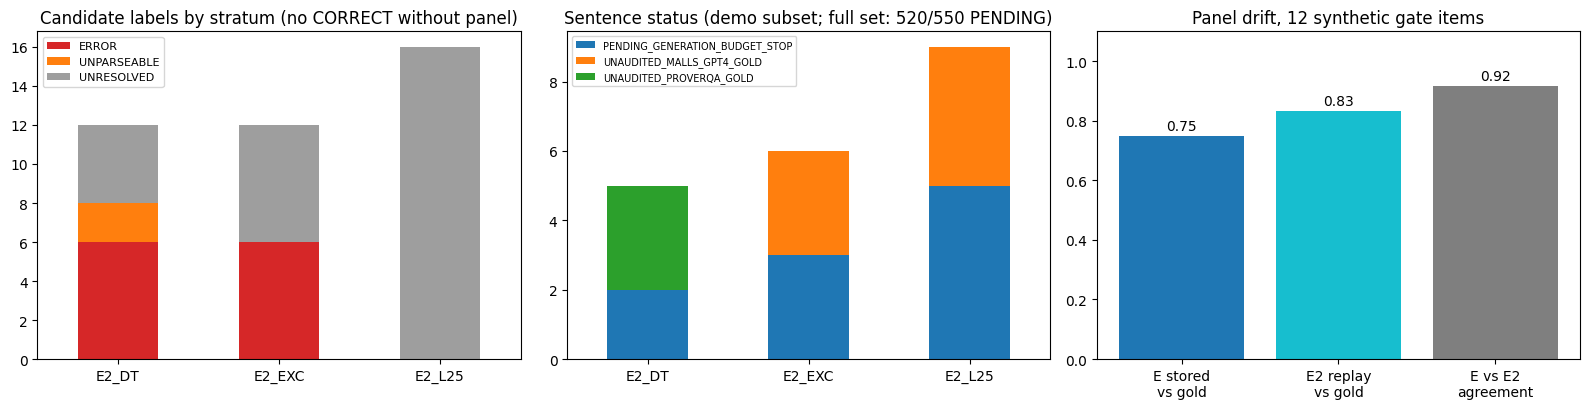

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ct = pd.crosstab(cand["fold"], cand["label"])
ct.plot(kind="bar", stacked=True, ax=ax[0], color={"ERROR": "#d62728", "UNRESOLVED": "#9e9e9e", "UNPARSEABLE": "#ff7f0e", "CORRECT": "#2ca02c"})
ax[0].set_title("Candidate labels by stratum (no CORRECT without panel)"); ax[0].set_xlabel(""); ax[0].tick_params(axis="x", rotation=0)
ax[0].legend(fontsize=8, loc="upper left")

st = pd.crosstab(sent["fold"], sent["status"])
st.plot(kind="bar", stacked=True, ax=ax[1])
ax[1].set_title("Sentence status (demo subset; full set: 520/550 PENDING)"); ax[1].set_xlabel(""); ax[1].tick_params(axis="x", rotation=0)
ax[1].legend(fontsize=7)

acc = {"E stored\nvs gold": (drift.E_majority == drift.gold_faithful).mean(),
       "E2 replay\nvs gold": (drift.E2_majority == drift.gold_faithful).mean(),
       "E vs E2\nagreement": (drift.E_majority == drift.E2_majority).mean()}
ax[2].bar(list(acc), list(acc.values()), color=["#1f77b4", "#17becf", "#7f7f7f"])
for i, v in enumerate(acc.values()):
    ax[2].text(i, v + 0.02, f"{v:.2f}", ha="center")
ax[2].set_ylim(0, 1.1); ax[2].set_title(f"Panel drift, {len(drift)} synthetic gate items")
plt.tight_layout(); plt.show()